In [516]:
import pandas as pd
import numpy as np

import matplotlib
import matplotlib.pyplot as plt
import plotly_express as px
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
from sklearn.decomposition import NMF, PCA
from sklearn.preprocessing import normalize
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans

from scipy.stats import binom
from scipy.cluster.hierarchy import to_tree
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import squareform
from scipy.spatial.distance import pdist

import sys
sys.path.append("../../local_lib/")
from hac2 import HAC
from heatmap import plot_grid, plot_map, CorrelationHeatMap as CHM

In [572]:
px_template = 'plotly_white'
doc_str = 'chunk_str'
token_pattern = r"(?u)\b\w[\w']*\b"
min_ngram = 1
max_ngram = 1

In [517]:
DOC = pd.read_csv("ajtzibab-CHUNK.csv").set_index("chunk_id")

In [519]:
count_engine = CountVectorizer(ngram_range=(min_ngram, max_ngram), token_pattern=token_pattern)

In [520]:
CTM = pd.DataFrame(count_engine.fit_transform(DOC[doc_str]).toarray(), 
                   index=DOC.index, 
                   columns=count_engine.get_feature_names_out())

In [521]:
VOCAB = CTM.sum().to_frame('n')
VOCAB.index.name = 'term_str'
VOCAB['grams'] = VOCAB.apply(lambda x: len(x.name.split()), axis=1)

In [522]:
VOCAB['df'] = CTM.astype(bool).sum()
VOCAB['dp'] = VOCAB.df / len(CTM) 
VOCAB['dh'] = VOCAB.dp * np.log2(1/VOCAB.dp)

In [523]:
VOCAB.sample(10, weights='dh')

,n,grams,df,dp,dh
term_str,,,,,
kawachinik,1,1,1,0.02,0.112877
chik'oje,3,1,3,0.06,0.243534
rib,37,1,20,0.40,0.528771
rochoch,19,1,10,0.20,0.464386
ketz'itilajik,1,1,1,0.02,0.112877
chupinaq,1,1,1,0.02,0.112877
kixtik'e,1,1,1,0.02,0.112877
eleq'axik,2,1,2,0.04,0.185754
wub,8,1,5,0.10,0.332193


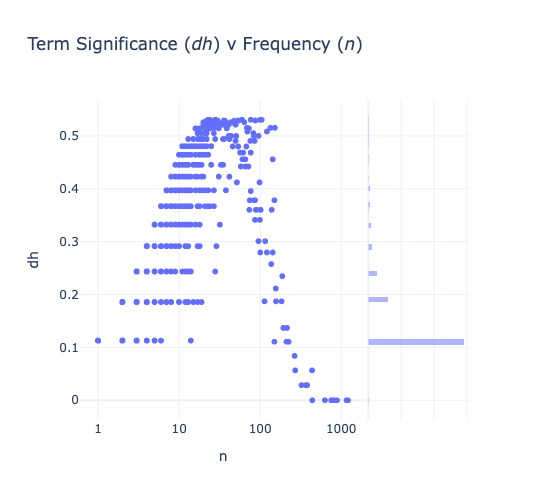

In [573]:
px.scatter(VOCAB.reset_index(), 'n', 'dh', 
           log_x=True, 
           width=750, height=500,
           hover_name='term_str',
           marginal_y='histogram',
           template=px_template,
          title="Term Significance (<i>dh</i>) v Frequency (<i>n</i>)")

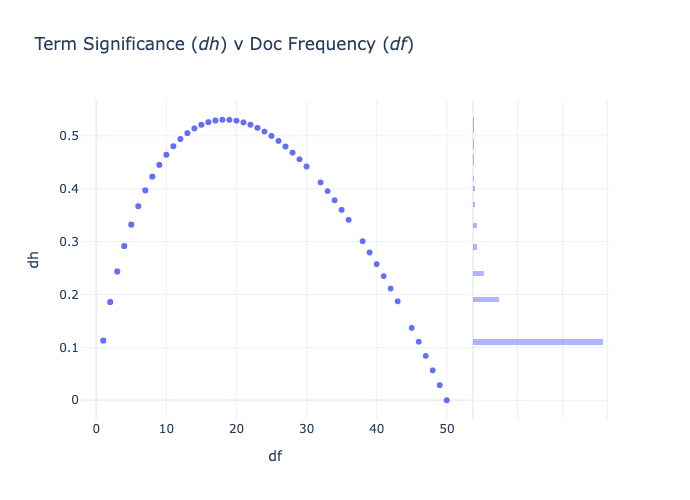

In [574]:
px.scatter(VOCAB.reset_index(), 'df', 'dh', 
           log_x=False, 
           width=750, height=500,
           hover_name='term_str',
           marginal_y='histogram',
           template=px_template,
          title="Term Significance (<i>dh</i>) v Doc Frequency (<i>df</i>)")

In [526]:
VOCAB.describe()

,n,grams,df,dp,dh
count,4280.000000,4280.0,4280.000000,4280.000000,4280.000000
mean,6.137617,1.0,2.585047,0.051701,0.164483
std,40.535421,0.0,5.127335,0.102547,0.097539
min,1.000000,1.0,1.000000,0.020000,0.000000
25%,1.000000,1.0,1.000000,0.020000,0.112877
50%,1.000000,1.0,1.000000,0.020000,0.112877
75%,2.000000,1.0,2.000000,0.040000,0.185754
max,1224.000000,1.0,50.000000,1.000000,0.530615


In [527]:
max_entropy = VOCAB.dh.mean()
max_entropy

0.1644826587530482

In [528]:
stop_mask = VOCAB.dh < max_entropy
SIGS = VOCAB[~stop_mask].index.tolist()
stopwords = VOCAB[stop_mask].index.tolist()

In [529]:
CTMX = CTM[SIGS]
tfidf_engine = TfidfTransformer(norm='l2', use_idf=True, smooth_idf=True)
TFIDF = pd.DataFrame(tfidf_engine.fit_transform(CTMX).toarray(), columns=CTMX.columns, index=CTMX.index)    
TFIDF_SIM = pd.DataFrame(cosine_similarity(TFIDF), index=TFIDF.index)

In [530]:
TOKEN

,token_str,term_str,chunk_id
token_id,,,
0,NaN,NaN,1
1,Are’,are’,1
2,uxe’,uxe’,1
3,ojer,ojer,1
4,tzij,tzij,1
...,...,...,...
27368,konojel,konojel,50
27369,K'iche',k'iche',50
27370,Sta.,sta,50


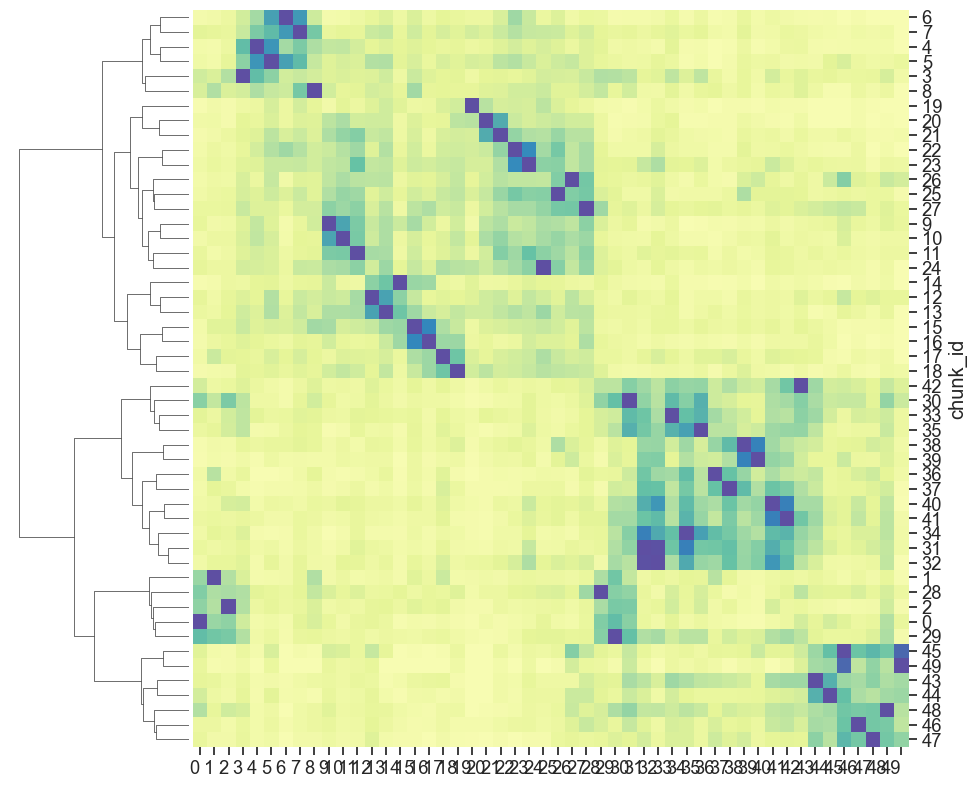

In [531]:
fig = sns.clustermap(TFIDF_SIM, 
               method='ward', metric='euclidean',
               cmap='Spectral', center=0, cbar_pos=None, 
               col_cluster=False, robust=True, 
               xticklabels=True, yticklabels=True)
plt.setp(fig.ax_heatmap.get_xticklabels(), rotation=0, ha="right")
fig.ax_col_dendrogram.set_visible(False)

<Figure size 640x480 with 0 Axes>

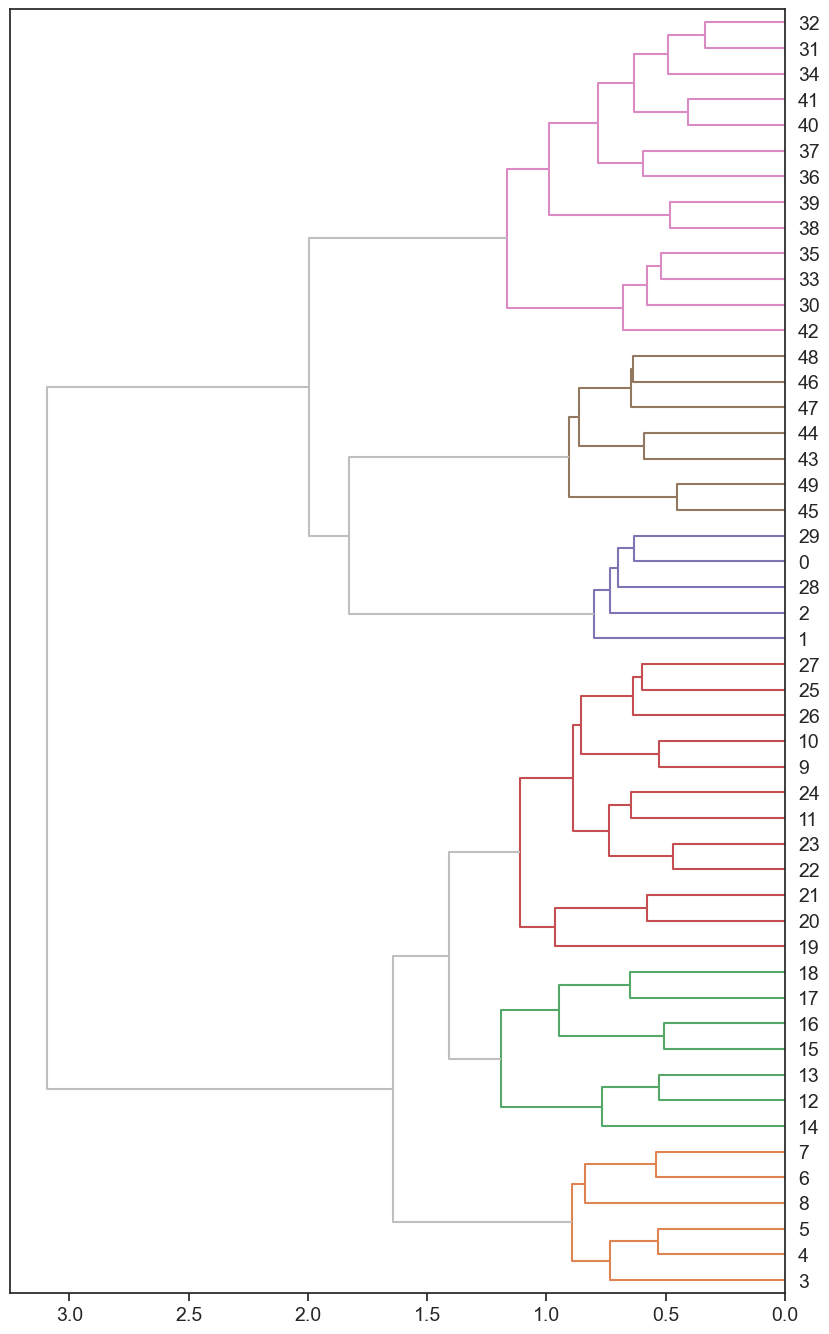

In [532]:
tfidf_hac = HAC(TFIDF_SIM)
tfidf_hac.color_thresh = 1.3
tfidf_hac.plot()

In [533]:
tfidf_hac.get_cluster_labels()

In [534]:
DOC['hac_label'] = tfidf_hac.CLUSTER_LABELS

In [535]:
k = len(set(tfidf_hac.CLUSTER_LABELS))
k

6

In [536]:
CLUSTER = DOC.hac_label.value_counts().to_frame('n_chunks')

In [537]:
CLUSTER

,n_chunks
hac_label,
4,13
2,12
3,7
6,7
1,6
5,5


In [538]:
label_col = "hac_label"

In [539]:
CLUSTER['gloss'] = TFIDF.join(DOC[label_col]).groupby(label_col).mean().idxmax(1)
CLUSTER['top_terms'] = TFIDF.join(DOC[label_col]).groupby(label_col).mean().apply(lambda x: ', '.join(x.sort_values(ascending=False).head(7).index), axis=1)

In [540]:
CLUSTER.sort_index()

,n_chunks,gloss,top_terms
hac_label,,,
1,6,kaqix,"kaqix, sipakna, k'ajolab, wuqub, kab'raqan, xc..."
2,12,xib'alb'a,"xib'alb'a, kame, ajpu, te, xcha, wuqub, b'a"
3,7,q'apoj,"q'apoj, kati't, che, ch'o, ati't, chowen, qati't"
4,13,b'alam,"b'alam, tojil, amaq, k'itze, q'ij, majukutaj, ..."
5,5,kaj,"kaj, ulew, k'ajolom, alom, b'itol, tz'aqol, winaq"
6,7,ajaw,"ajaw, ajpop, ajawab, unim, k'iche, q'alel, tin..."


In [541]:
# pca_engine = PCA(n_components=k + (k % 2))
pca_engine = PCA(n_components=10)
PCAX = pd.DataFrame(pca_engine.fit_transform(TFIDF), index=TFIDF.index)
PCAX.index.name = 'doc_id'
LOADINGS = pd.DataFrame(pca_engine.components_.T * np.sqrt(pca_engine.explained_variance_), index = TFIDF.columns)
LOADINGS.index.name = 'term_str'

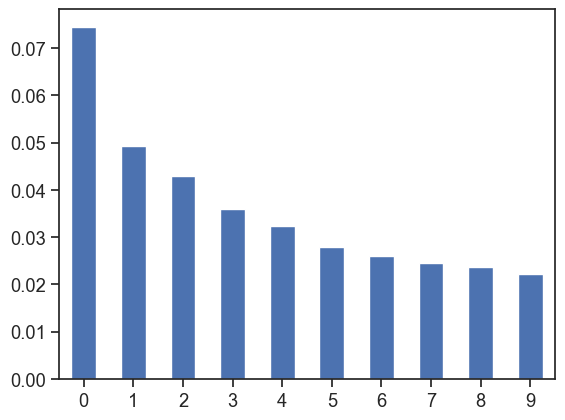

In [542]:
pd.Series(pca_engine.explained_variance_).plot.bar(rot=0);

In [575]:
X0 = DOC.join(PCAX).join(CLUSTER, on=label_col)

def plot_pca(x, y):

    px.scatter(X0, x, y, 
        text=X0.index, 
        height=850, width=950, 
        color=X0.gloss,
        size = [1 for i in range(len(X0))],
        template=px_template,
        marginal_x='box', 
        marginal_y='box').show()

    quantile = .99
    A = LOADINGS.loc[np.abs(LOADINGS[x]) >= np.abs(LOADINGS[x]).quantile(quantile), x]
    B = LOADINGS.loc[np.abs(LOADINGS[y]) >= np.abs(LOADINGS[y]).quantile(quantile), y]    
    C = pd.concat([A,B], axis=1).index
    
    px.scatter(LOADINGS.loc[C].join(VOCAB), x, y, 
        title=f"Quantile {quantile} Loadings for {x} and {y}",
        opacity=.5,
        text=C, 
        size='n',
        template=px_template,
        height=850, width=950).show()
    

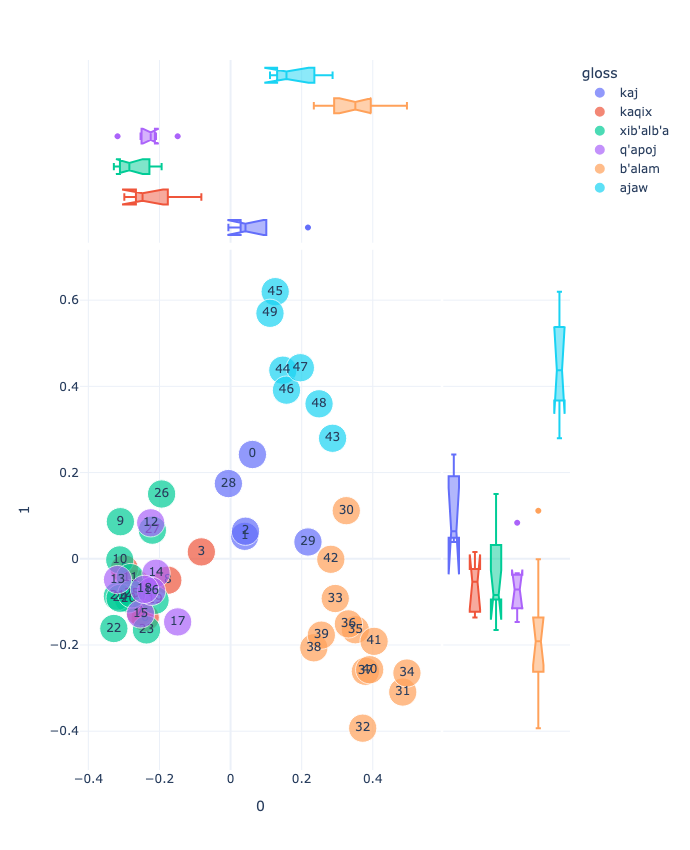

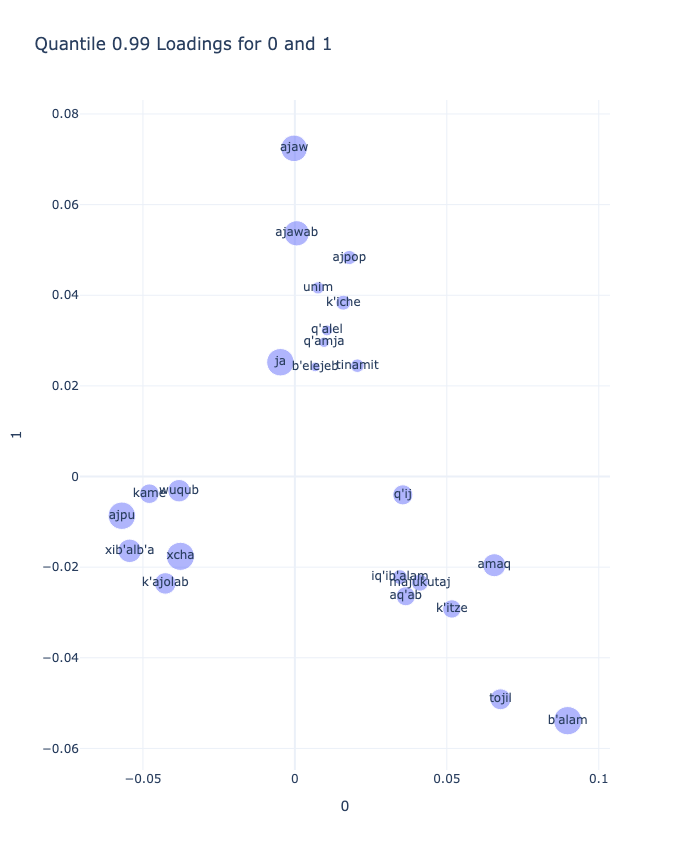

In [576]:
plot_pca(0,1)

In [577]:
n_topic_terms = 10
nmf_engine = NMF(n_components=k, max_iter=5000, init='nndsvda', solver='mu', beta_loss='kullback-leibler')
THETA = pd.DataFrame(nmf_engine.fit_transform(TFIDF), index=TFIDF.index)
THETA_SIM = pd.DataFrame(cosine_similarity(THETA), index=THETA.index, columns=THETA.index)
PHI = pd.DataFrame(nmf_engine.components_, columns=TFIDF.columns)
TOPIC = PHI.T.apply(lambda x: ', '.join(x.sort_values(ascending=False).head(n_topic_terms).index)).T.to_frame('top_terms')
TOPIC.index.name = 'topic_id'
DOC[f'top_topic_{k}'] = THETA.idxmax(1).values

In [578]:
with open("topics.md", "w") as outfile:
    TOPIC.to_markdown(outfile)

In [560]:
TOPIC['gloss'] = PHI.idxmax(1)

In [561]:
TOPIC

,top_terms,gloss
topic_id,,
0,"xib'alb'a, kame, ajpu, te, wuqub, xcha, b'a, l...",xib'alb'a
1,"b'alam, tojil, amaq, k'itze, majukutaj, aq'ab,...",b'alam
2,"ajaw, ajpop, ajawab, k'iche, unim, q'alel, tin...",ajaw
3,"kaj, ulew, winaq, k'ajolom, alom, b'itol, tz'a...",kaj
4,"kaqix, sipakna, k'ajolab, wuqub, kab'raqan, xc...",kaqix
5,"q'apoj, kati't, che, ati't, ch'o, chowen, qati...",q'apoj


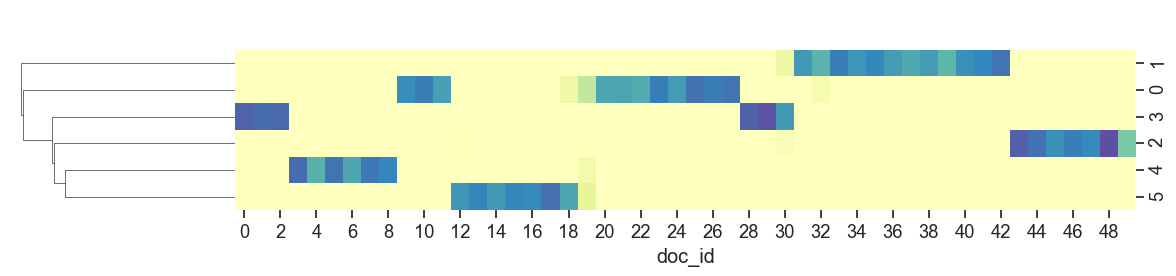

In [593]:
fig = sns.clustermap(THETA.T, 
    cmap='Spectral', 
    center=0, 
    metric='euclidean',
    method='ward', 
    cbar_pos=None,
    row_cluster=True, 
    col_cluster=False,
    figsize=(12,3)
)

In [588]:
sns.clustermap?

Signature:
sns.clustermap(
    data,
    *,
    pivot_kws=None,
    method='average',
    metric='euclidean',
    z_score=None,
    standard_scale=None,
    figsize=(10, 10),
    cbar_kws=None,
    row_cluster=True,
    col_cluster=True,
    row_linkage=None,
    col_linkage=None,
    row_colors=None,
    col_colors=None,
    mask=None,
    dendrogram_ratio=0.2,
    colors_ratio=0.03,
    cbar_pos=(0.02, 0.8, 0.05, 0.18),
    tree_kws=None,
    **kwargs,
)
Docstring:
Plot a matrix dataset as a hierarchically-clustered heatmap.

This function requires scipy to be available.

Parameters
----------
data : 2D array-like
    Rectangular data for clustering. Cannot contain NAs.
pivot_kws : dict, optional
    If `data` is a tidy dataframe, can provide keyword arguments for
    pivot to create a rectangular dataframe.
method : str, optional
    Linkage method to use for calculating clusters. See
    :func:`scipy.cluster.hierarchy.linkage` documentation for more
    information.
metric : str, o